<a href="https://colab.research.google.com/github/aditi-tawade-ai/SkillBuilding/blob/main/Notebook/Social_newtwork_class_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
path = '/content/Social_Net_class.csv'
s = pd.read_csv(path)
s[:3]

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


In [ ]:
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
s.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
s.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
s.Purchased.unique()

array([0, 1])

In [ ]:
s.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
gn = s['Gender'].replace({'Male':0,'Female':1})
s['Gender'] = gn
s[:5]

/tmp/ipykernel_1850/390124432.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gn = s['Gender'].replace({'Male':0,'Female':1})


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


In [ ]:
X = s.iloc[:,:-1]
X[:2]

,User ID,Gender,Age,EstimatedSalary
0,15624510,0,19,19000
1,15810944,0,35,20000


In [ ]:
y = s.iloc[:,4]
y[:2]

,Purchased
0,0
1,0


# Spliting the data

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.score(X_train,y_train)*100

83.75

In [ ]:
X_train[:5]

,User ID,Gender,Age,EstimatedSalary
111,15660200,1,37,71000
224,15575002,1,35,60000
332,15769902,0,42,65000
183,15603319,0,33,43000
351,15591279,0,37,75000


In [ ]:
# testing data
y_pred = knn.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1])

In [ ]:
y_test.values

array([1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [ ]:
print('Accuracy is:',knn.score(X_test,y_test)*100)

Accuracy is: 61.25000000000001


we have got the Accuracy but we need confusion matrix to check the models score

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,y_pred)
cm

array([[37,  5],
       [26, 12]])

Text(50.72222222222221, 0.5, 'Actual')

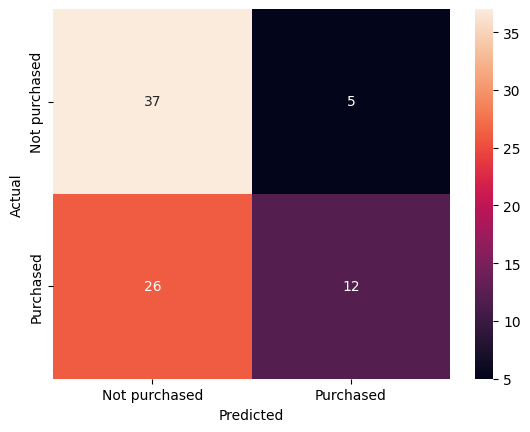

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True,
            xticklabels=['Not purchased','Purchased'],yticklabels=['Not purchased','Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
#actual record of class 0
sum(y_test==0)

42

In [ ]:
sum(y_pred==0)

np.int64(63)

In [ ]:
sum(y_test==1)

38

In [ ]:
sum(y_pred==1)

np.int64(17)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.59      0.88      0.70        42
           1       0.71      0.32      0.44        38

    accuracy                           0.61        80
   macro avg       0.65      0.60      0.57        80
weighted avg       0.64      0.61      0.58        80



# Find the value of k using precision

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [ ]:
p_list = []
n_list=[]
for i in range(1,11):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  p_list.append(precision_score(y_test,y_pred))
  n_list.append(i)

In [ ]:
p_list

[0.5833333333333334,
 0.6666666666666666,
 0.6363636363636364,
 0.7142857142857143,
 0.7058823529411765,
 0.7857142857142857,
 0.7647058823529411,
 0.8,
 0.7647058823529411,
 0.8571428571428571]

In [ ]:
n_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Text(0.5, 1.0, 'precision score vs k value')

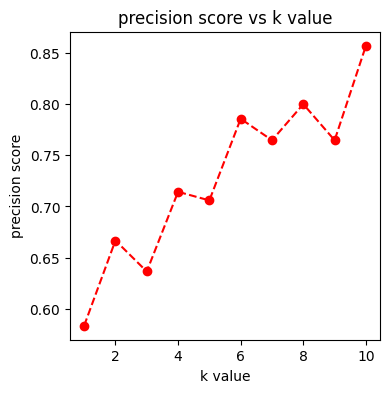

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(n_list,p_list,'r--o')
plt.xlabel('k value')
plt.ylabel('precision score')
plt.title('precision score vs k value')

# finding k using f1 score

In [ ]:
f1_list = []
k_list = []
for k in range(1,11):
  clf = KNeighborsClassifier(n_neighbors=k)
  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)
  f1_list.append(f1_score(y_test,y_pred))
  k_list.append(k)

In [ ]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
print(f1_list)

[0.45161290322580644, 0.32, 0.4666666666666667, 0.38461538461538464, 0.43636363636363634, 0.4230769230769231, 0.4727272727272727, 0.4528301886792453, 0.4727272727272727, 0.46153846153846156]


In [ ]:
max(f1_list)

0.4727272727272727

In [ ]:
f1_list.index(max(f1_list))

6

Text(0.5, 1.0, 'f1 score vs k value')

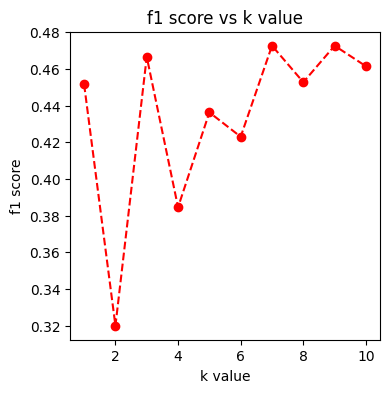

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,f1_list,'r--o')
plt.xlabel('k value')
plt.ylabel('f1 score')
plt.title('f1 score vs k value')


from above map we can see that the score is highest for the k value=2 so we choose neighbors=2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_1 = KNeighborsClassifier(n_neighbors=5)
model_1.fit(X_train,y_train)
model_1.score(X_train,y_train)*100

83.75

# finding k value using recall score

In [ ]:
c_list = []
i_list = []
for i in range(1,11):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  c_list.append(recall_score(y_test,y_pred))
  i_list.append(i)


In [ ]:
c_list

[0.3684210526315789,
 0.21052631578947367,
 0.3684210526315789,
 0.2631578947368421,
 0.3157894736842105,
 0.2894736842105263,
 0.34210526315789475,
 0.3157894736842105,
 0.34210526315789475,
 0.3157894736842105]

Text(0.5, 1.0, 'recall score vs k value')

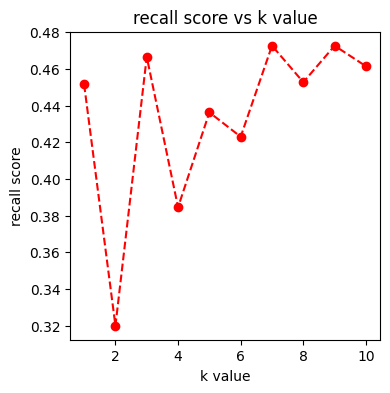

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,f1_list,'r--o')
plt.xlabel('k value')
plt.ylabel('recall score')
plt.title('recall score vs k value')

k = 2

# finding k value using error rate

In [ ]:
y_test.values

array([1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [ ]:
error_rate = []
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
print(error_rate)

[np.float64(0.425), np.float64(0.425), np.float64(0.4), np.float64(0.4), np.float64(0.3875), np.float64(0.375), np.float64(0.3625), np.float64(0.3625), np.float64(0.3625), np.float64(0.35)]


In [ ]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
min(error_rate)

np.float64(0.35)

In [ ]:
error_rate.index(min(error_rate))

9

Text(0.5, 1.0, 'error rate vs k value')

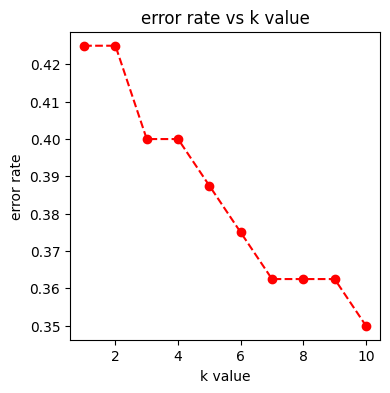

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,error_rate,'r--o')
plt.xlabel('k value')
plt.ylabel('error rate')
plt.title('error rate vs k value')

from above graph we can see error is minimum at 2

next import pkl file and save

# **Revision**

Q1. What is KNN?
- KNN - is supervised learning algorithm used for both regression and classification
- It finds the k nearest data point to a new data point using a distance metrics such as Euclidean distance
- When its classification we take majority and for regression we take mean of all the k nearest values
- It is also called as lazy learning algorithm becoz it calculates the distance with all points

Q2.Explain working of KNN?
- Step1: choose the value of k it is the number of close neighbors
- Step2: calculate distance between new data points and existing data points
- Step3: find best k neighbors to the new data points from all training data
- Step4: take majority class for classification problem or take mean of all nearest values for regression problem
- Step5: Model is ready

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
path = '/content/Social_Net_class.csv'
s = pd.read_csv(path)
s[:2]

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


# Analysis of the dataset

In [ ]:
len(s)

400

In [ ]:
s.shape

(400, 5)

In [ ]:
s.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
s.Gender.unique()

array(['Male', 'Female'], dtype=object)

# Preprocessing

In [ ]:
s.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


No missing data

In [ ]:
# encoding the gender column
gn = s['Gender'].replace({'Male':0 ,'Female':1})
s['Gender'] = gn
s[:2]

/tmp/ipykernel_1850/819699202.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gn = s['Gender'].replace({'Male':0 ,'Female':1})


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0


In [ ]:
# seperating the input and output data
X = s[['Gender','Age','EstimatedSalary']]
y = s['Purchased']

In [ ]:
X[:2]

,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000


In [ ]:
y[:2]

,Purchased
0,0
1,0


In [ ]:
# scaling the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
X[:2]

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138]])

This is the last step of preprocessing.The numeric data is scaled in a similer range

# Spliting the data

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
X_train[:5]

array([[ 0.98019606,  0.31949142, -0.28608712],
       [ 0.98019606,  0.89257019, -1.16703281],
       [ 0.98019606,  1.5611621 ,  1.123426  ],
       [ 0.98019606,  1.65667523,  1.76945285],
       [-1.02020406,  0.31949142, -0.31545197]])

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 3)
(80, 3)
(320,)
(80,)


In [ ]:
y_test.values

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.score(X_train,y_train)*100

91.5625

In [ ]:
y_pred = knn.predict(X_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1])

Accuracy is 91%

In [ ]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[53,  4],
       [ 2, 21]])

Text(50.72222222222221, 0.5, 'Actual')

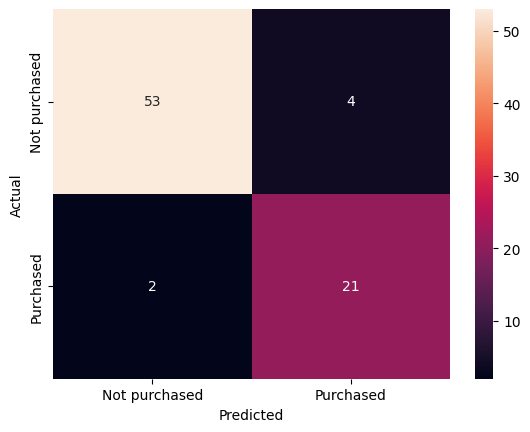

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True,
            xticklabels=['Not purchased','Purchased'],yticklabels=['Not purchased','Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95        57
           1       0.84      0.91      0.88        23

    accuracy                           0.93        80
   macro avg       0.90      0.92      0.91        80
weighted avg       0.93      0.93      0.93        80



In [ ]:
print(precision_score(y_test,y_pred)*100)

84.0


In [ ]:
print(recall_score(y_test,y_pred)*100)

91.30434782608695


In [ ]:
print(f1_score(y_test,y_pred)*100)

87.5


since precision score is greater we will go with precision method to find the k

# Finding k using precision score

In [ ]:
pr = []
k = []
for i in range(1,11):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  pr.append(precision_score(y_test,y_pred))
  k.append(i)


In [ ]:
pr

[0.8095238095238095,
 0.875,
 0.8260869565217391,
 0.8947368421052632,
 0.84,
 0.8636363636363636,
 0.8695652173913043,
 0.8695652173913043,
 0.8333333333333334,
 0.8695652173913043]

Text(0.5, 1.0, 'precision score vs k value')

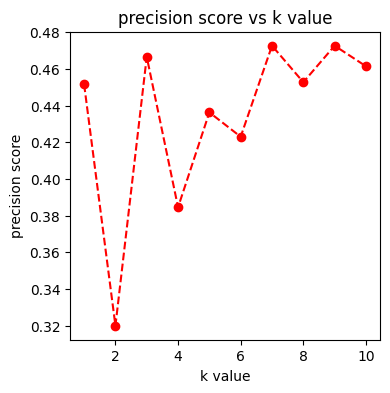

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,f1_list,'r--o')
plt.xlabel('k value')
plt.ylabel('precision score')
plt.title('precision score vs k value')

# Finding k value using error rate

In [ ]:
error_rate = []
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
print(error_rate)

[np.float64(0.125), np.float64(0.1375), np.float64(0.1), np.float64(0.1), np.float64(0.075), np.float64(0.0875), np.float64(0.075), np.float64(0.075), np.float64(0.0875), np.float64(0.075)]


In [ ]:
error_rate

[np.float64(0.125),
 np.float64(0.1375),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.075),
 np.float64(0.0875),
 np.float64(0.075),
 np.float64(0.075),
 np.float64(0.0875),
 np.float64(0.075)]

Text(0.5, 1.0, 'error rate vs k value')

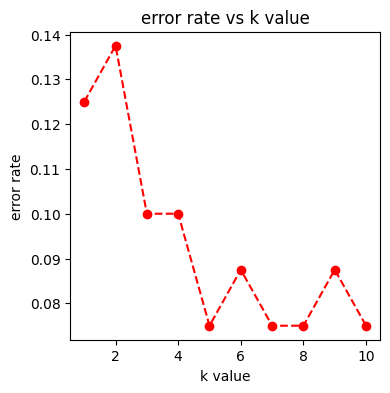

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,error_rate,'r--o')
plt.xlabel('k value')
plt.ylabel('error rate')
plt.title('error rate vs k value')

comparing 2 graphs we choose 7 as k value

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
fm = KNeighborsClassifier(n_neighbors=7)
fm.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = fm.predict(X_test)
y_pred

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
y_test.values

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
accuracy = fm.score(X_test,y_test)*100
accuracy

92.5

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,y_pred)
cm

array([[54,  3],
       [ 3, 20]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        57
           1       0.87      0.87      0.87        23

    accuracy                           0.93        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.93      0.93      0.93        80



In [ ]:
import pickle
with open('knn.pkl','wb') as file:
  pickle.dump(fm,file)

In [ ]:
sc = StandardScaler()
X = sc.fit_transform(X)
X[:2]

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138]])

In [ ]:
import joblib

# Save the trained KNN model
joblib.dump(fm, "knn.pkl")

# Save the scaler
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']